# Analyses factorielles — rythmes et profils de logements



## 1. Le tableau de contingence


In [49]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 40)

DATA = '../data/cln1/Raw'
IDN_EXTERIEUR = 90


In [ ]:
#  Présence déclarée par logement et par heure
sem = pd.read_csv(f'{DATA}/Questionnaires_Comportement/CNL1_SEMAINIER_DATA.txt',
                  sep='\t', encoding='latin1')
sem = sem[sem['CODE_HEURE'].str.startswith('V_1')].copy()
sem['tranche'] = sem['CODE_HEURE'].str[2:].astype(int) - 1001
sem['heure'] = sem['tranche'] // 6

cap = (pd.read_csv(f'{DATA}/Mesures_Confort_Dynamique/CNL1_SERIE_CO2.txt', sep='\t',
                   encoding='latin1', usecols=['CODELIEU', 'IDN_PIECE'])
       .groupby('CODELIEU')['IDN_PIECE'].first())
sem['piece_capteur'] = sem['CODELIEU'].map(cap)
renseigne = sem['IDN_PIECE'].notna()
sem['dans_piece'] = renseigne & (sem['IDN_PIECE'] == sem['piece_capteur'])


T = (sem[sem['dans_piece']].groupby(['CODELIEU', 'heure']).size()
     .unstack(fill_value=0).reindex(columns=range(24), fill_value=0))

# Les logements très peu occupés donnent un profil instable 
SEUIL = 50
n_avant = len(T)
T = T[T.sum(axis=1) >= SEUIL]

print(f'{n_avant} logements → {len(T)} après filtre (≥ {SEUIL} tranches occupées)')
print(f'{T.values.sum():,} tranches occupées au total')
display(T.iloc[:5, :12])


488 logements → 482 après filtre (≥ 50 tranches occupées)
283,522 tranches occupées au total


heure,0,1,2,3,4,5,6,7,8,9,10,11
CODELIEU,,,,,,,,,,,,
01-M001,84,84,84,84,84,84,42,30,26,6,6,18
01-M002,30,30,30,30,30,30,30,24,3,0,0,0
01-M004,36,36,36,36,36,36,31,36,33,22,14,15
01-M013,41,42,42,42,42,42,41,35,25,21,16,14
01-M019,37,42,42,42,42,42,31,1,0,0,0,0


,valeur propre,% inertie,% cumulé
axe 1,0.147,40.443,40.443
axe 2,0.067,18.530,58.973
axe 3,0.031,8.427,67.400
axe 4,0.025,6.814,74.215
axe 5,0.019,5.205,79.420
axe 6,0.014,3.951,83.371
axe 7,0.010,2.771,86.141
axe 8,0.009,2.371,88.513


Inertie totale : 0.3637
Chi² = 103,105  (ddl = 11,063)


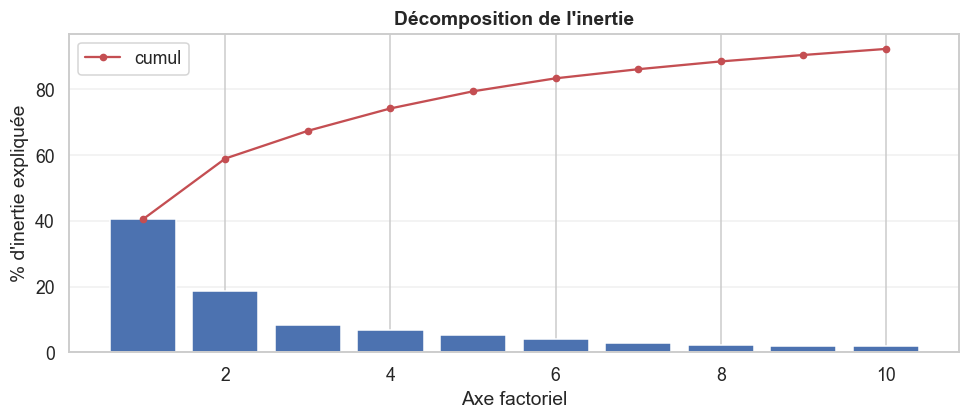

In [51]:
N = T.values.astype(float)
n = N.sum()
P = N / n                                  # fréquences relatives
r_m, c_m = P.sum(axis=1), P.sum(axis=0)    # marges lignes et colonnes
E = np.outer(r_m, c_m)                     # tableau attendu sous indépendance

S = (P - E) / np.sqrt(E)                   # écarts standardisés
U, sv, Vt = np.linalg.svd(S, full_matrices=False)

inertie = sv ** 2
pct = 100 * inertie / inertie.sum()

recap = pd.DataFrame({
    'valeur propre': inertie[:8],
    '% inertie': pct[:8],
    '% cumulé': np.cumsum(pct[:8]),
}, index=[f'axe {i+1}' for i in range(8)])
display(recap.round(3))

print(f'Inertie totale : {inertie.sum():.4f}')
print(f'Chi² = {inertie.sum() * n:,.0f}  (ddl = {(N.shape[0]-1) * (N.shape[1]-1):,})')

# Coordonnées des lignes (logements) et des colonnes (heures)
coord_log = (U * sv) / np.sqrt(r_m)[:, None]
coord_h   = (Vt.T * sv) / np.sqrt(c_m)[:, None]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, 11), pct[:10], color='#4C72B0')
ax.plot(range(1, 11), np.cumsum(pct[:10]), color='#C44E52', marker='o', ms=4,
        label='cumul')
ax.set_xlabel('Axe factoriel'); ax.set_ylabel("% d'inertie expliquée")
ax.set_title("Décomposition de l'inertie", fontweight='bold')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


## 3. Ce que signifient les axes

Un axe se lit par les colonnes qui y contribuent le plus. La **contribution** d'une
heure mesure sa part dans la construction de l'axe ; les heures situées aux deux
extrémités définissent l'opposition qu'il exprime.


,axe 1,contrib. 1 (%),axe 2,contrib. 2 (%)
0h,0.156,1.6,0.037,0.2
1h,0.155,1.7,0.016,0.0
2h,0.151,1.6,0.000,0.0
3h,0.151,1.6,-0.012,0.0
4h,0.148,1.6,-0.020,0.1
5h,0.140,1.3,-0.044,0.3
6h,0.107,0.7,-0.118,1.8
7h,-0.052,0.1,-0.290,7.1
8h,-0.300,1.8,-0.521,11.8
9h,-0.626,3.8,-0.748,11.8


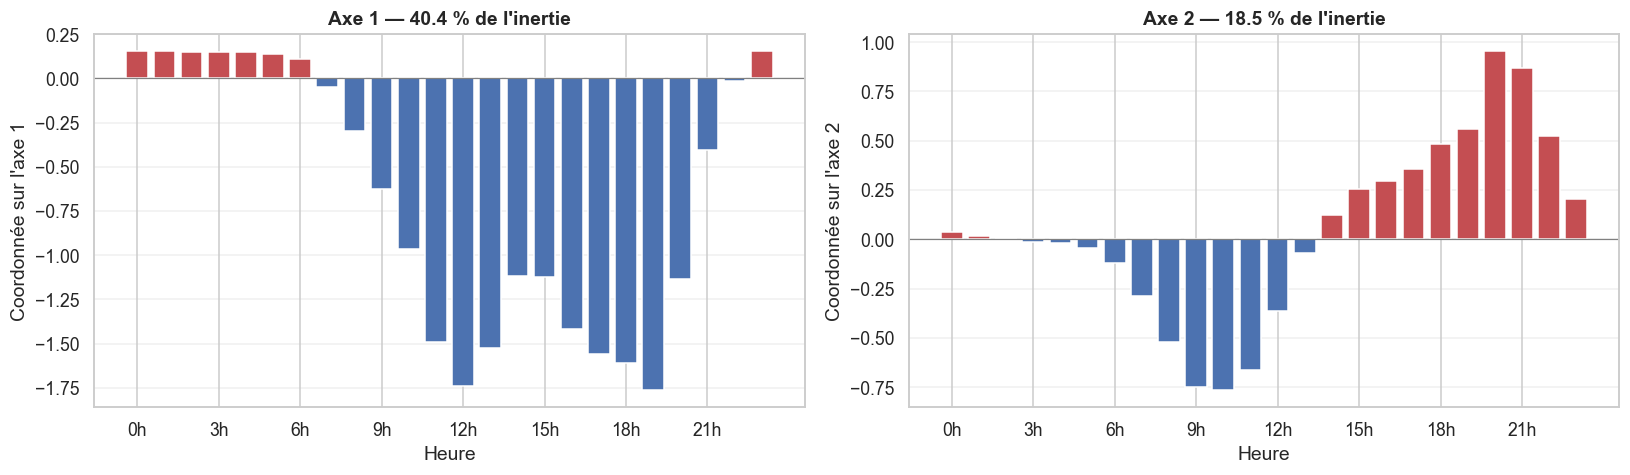

In [52]:
contrib = 100 * c_m[:, None] * coord_h**2 / inertie

axes_tab = pd.DataFrame({
    'axe 1': coord_h[:, 0].round(3),
    'contrib. 1 (%)': contrib[:, 0].round(1),
    'axe 2': coord_h[:, 1].round(3),
    'contrib. 2 (%)': contrib[:, 1].round(1),
}, index=[f'{h}h' for h in range(24)])
display(axes_tab)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for k, ax in enumerate(axes):
    couleurs = ['#C44E52' if v > 0 else '#4C72B0' for v in coord_h[:, k]]
    ax.bar(range(24), coord_h[:, k], color=couleurs)
    ax.axhline(0, color='grey', lw=0.8)
    ax.set_xticks(range(0, 24, 3))
    ax.set_xticklabels([f'{h}h' for h in range(0, 24, 3)])
    ax.set_xlabel('Heure'); ax.set_ylabel(f'Coordonnée sur l\'axe {k+1}')
    ax.set_title(f'Axe {k+1} — {pct[k]:.1f} % de l\'inertie', fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


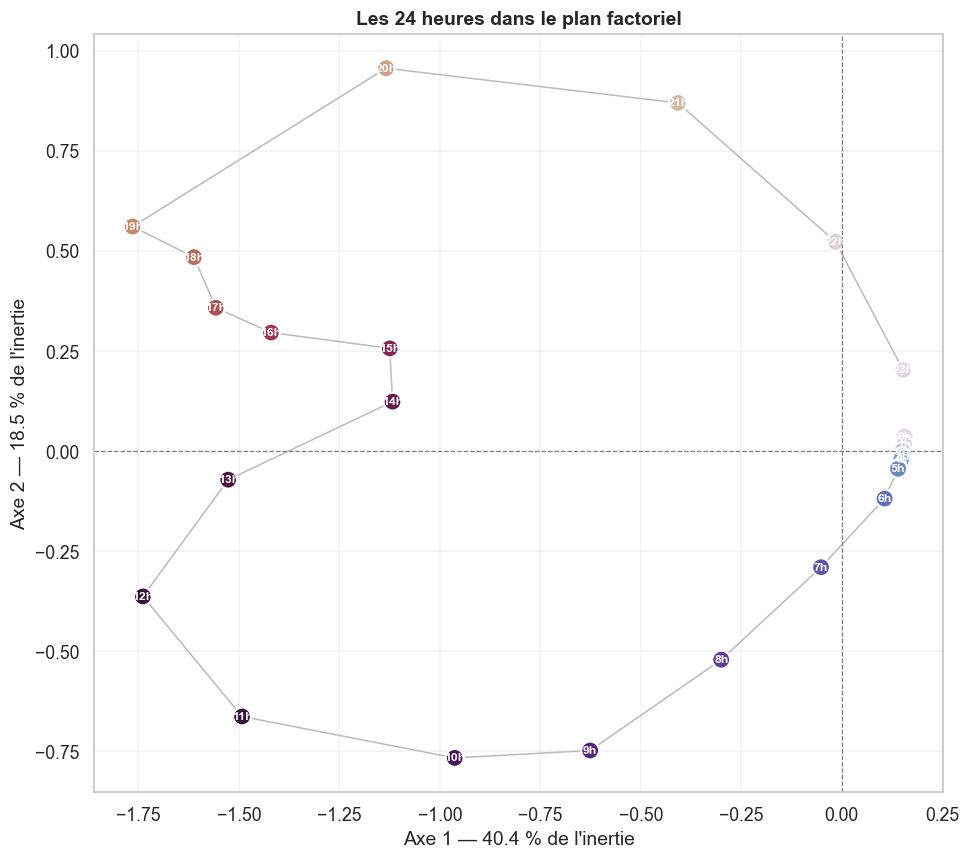

In [53]:
# Plan factoriel des heures : la trajectoire d'une journée
fig, ax = plt.subplots(figsize=(9, 8))

ax.plot(coord_h[:, 0], coord_h[:, 1], color='#BBBBBB', lw=1, zorder=1)
sc = ax.scatter(coord_h[:, 0], coord_h[:, 1], c=range(24), cmap='twilight',
                s=140, zorder=2, edgecolors='white', linewidths=1.5)
for h in range(24):
    ax.annotate(f'{h}h', (coord_h[h, 0], coord_h[h, 1]),
                fontsize=8, ha='center', va='center', zorder=3,
                color='white', fontweight='bold')

ax.axhline(0, color='grey', lw=0.8, ls='--'); ax.axvline(0, color='grey', lw=0.8, ls='--')
ax.set_xlabel(f'Axe 1 — {pct[0]:.1f} % de l\'inertie')
ax.set_ylabel(f'Axe 2 — {pct[1]:.1f} % de l\'inertie')
ax.set_title('Les 24 heures dans le plan factoriel', fontweight='bold')
ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()


## 4. Les logements dans ce plan

Chaque logement se projette selon son propre profil horaire. Deux logements
proches ont des rythmes semblables ; un logement proche d'une heure y est
relativement plus occupé que la moyenne.

On superpose ensuite leurs caractéristiques déclarées, en **variables
illustratives** : elles n'interviennent pas dans le calcul des axes, on se contente
d'y projeter le centre de gravité de chaque catégorie. C'est la façon usuelle de
vérifier si une variable extérieure s'aligne sur la structure trouvée.


In [ ]:
KVNT_LABELS = {1: 'VMC', 2: 'Extracteurs', 3: 'Naturelle', 4: 'Aucune'}
FC3_LABELS = {1: 'Maison individuelle', 2: 'Appart. collectif', 3: 'Studio collectif'}
STRMEN_LABELS = {1: 'Personne seule', 2: 'Famille monoparentale',
                 3: 'Couple', 4: 'Autre ménage'}
INDT_LABELS = {'1': 'Travaille', '2': 'Étudiant', '3': 'Ne travaille pas'}

q = pd.read_csv(f'{DATA}/Questionnaires_Comportement/CNL1_Q_LOGEMENT_MENAGE_DATA.csv',
                sep=';', encoding='latin1',
                usecols=['CODELIEU', 'KVNT', 'FC3', 'STRMEN', 'HSRF']).set_index('CODELIEU')
num = lambda c: pd.to_numeric(q[c], errors='coerce')

q_ind = pd.read_csv(f'{DATA}/Questionnaires_Comportement/CNL1_Q_INDIVIDU_DATA.csv',
                    sep=';', encoding='latin1',
                    usecols=['CODELIEU', 'INDT'], dtype={'INDT': str})
actif = q_ind.groupby('CODELIEU')['INDT'].apply(lambda s: (s == '1').any())

L = pd.DataFrame(index=T.index)
L['axe1'] = coord_log[:, 0]
L['axe2'] = coord_log[:, 1]
L['ventilation']   = num('KVNT').map(KVNT_LABELS)
L['type_logement'] = num('FC3').map(FC3_LABELS)
L['menage']        = num('STRMEN').map(STRMEN_LABELS)
L['surface']       = num('HSRF')
L['actif'] = L.index.map(actif).map({True: 'Au moins un actif', False: 'Aucun actif'})


nuit = T[[0, 1, 2, 3, 4, 5]].sum(axis=1)
jour = T[[10, 11, 12, 13, 14, 15]].sum(axis=1)
L['contraste_profil'] = (nuit - jour) / T.sum(axis=1)


nuit_t = sem[sem['heure'] < 6].groupby('CODELIEU')[
    'dans_piece'].mean()
jour_t = sem[sem['heure'].between(10, 15)].groupby('CODELIEU')[
    'dans_piece'].mean()
L['contraste_taux'] = (nuit_t - jour_t).reindex(L.index)
L['presence_totale'] = sem.groupby('CODELIEU')['dans_piece'].mean().reindex(L.index)

print(f'{len(L)} logements projetés')
display(L[['axe1', 'axe2', 'surface', 'contraste_profil', 'contraste_taux',
           'presence_totale']].describe().round(3))


482 logements projetés


,axe1,axe2,surface,contraste_profil,contraste_taux,presence_totale
count,482.000,482.000,476.000,482.000,482.000,482.000
mean,0.024,-0.013,111.876,0.590,0.586,0.260
std,0.381,0.271,63.438,0.157,0.281,0.127
min,-2.124,-1.289,12.000,-0.337,-0.437,0.030
25%,-0.069,-0.169,71.000,0.537,0.360,0.161
50%,0.140,-0.003,98.000,0.624,0.548,0.238
75%,0.261,0.159,140.000,0.685,0.857,0.357
max,0.384,0.740,600.000,0.949,1.000,0.799


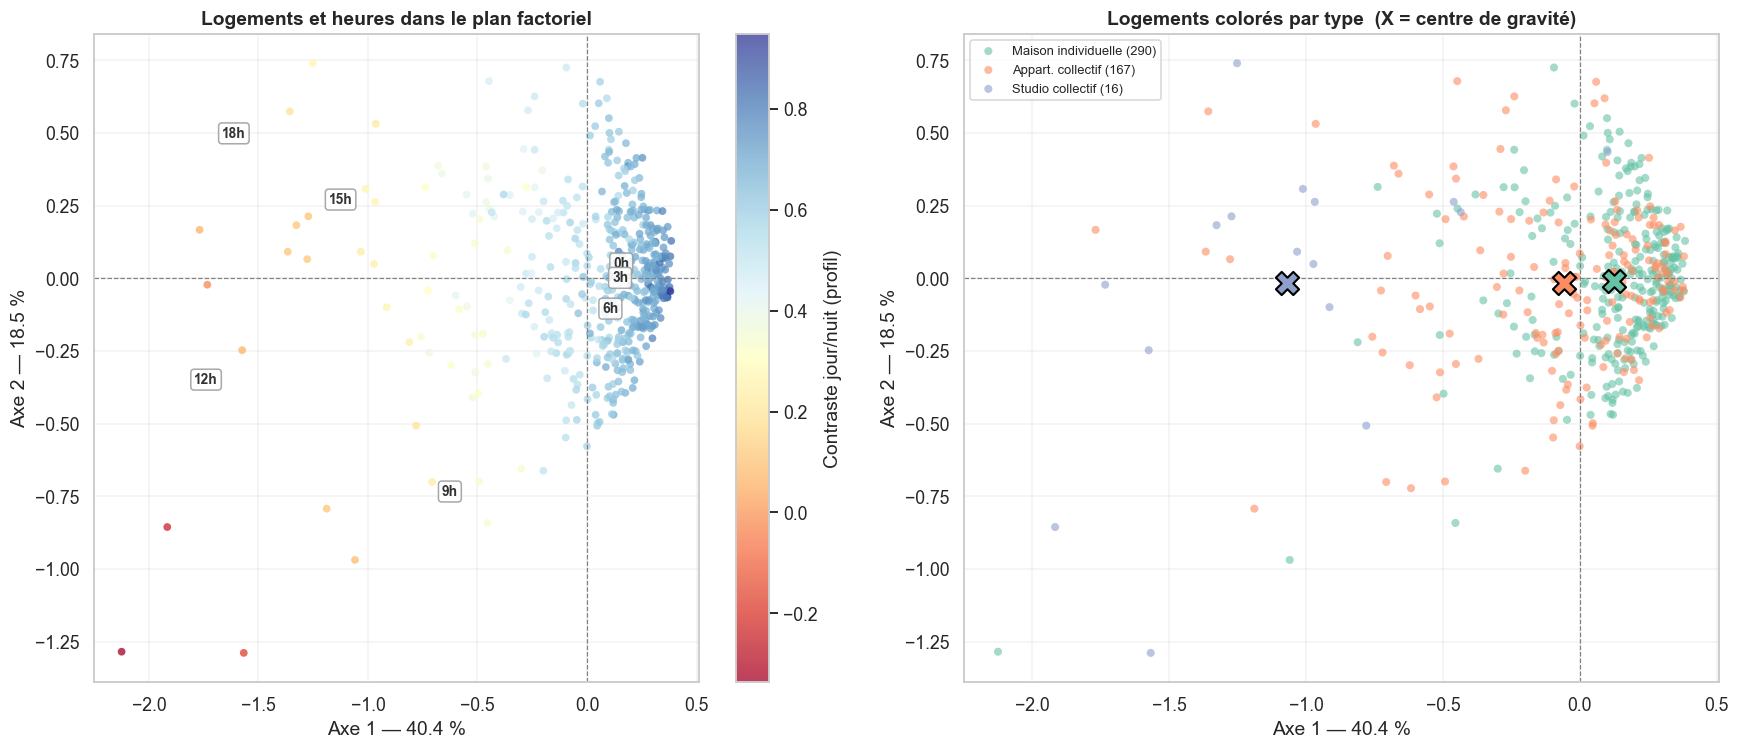

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Nuage coloré par le contraste jour/nuit
ax = axes[0]
sc = ax.scatter(L['axe1'], L['axe2'], c=L['contraste_profil'], cmap='RdYlBu',
                s=26, alpha=0.75, edgecolors='none')
plt.colorbar(sc, ax=ax, label='Contraste jour/nuit (profil)')
for h in [0, 3, 6, 9, 12, 15, 18, 21]:
    ax.annotate(f'{h}h', (coord_h[h, 0], coord_h[h, 1]), fontsize=9,
                fontweight='bold', color='#333333', ha='center',
                bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='#999999', alpha=0.85))
ax.axhline(0, color='grey', lw=0.8, ls='--'); ax.axvline(0, color='grey', lw=0.8, ls='--')
ax.set_xlabel(f'Axe 1 — {pct[0]:.1f} %'); ax.set_ylabel(f'Axe 2 — {pct[1]:.1f} %')
ax.set_title('Logements et heures dans le plan factoriel', fontweight='bold')
ax.grid(True, alpha=0.25)

# ── Nuage coloré par le type de logement
ax = axes[1]
sub = L.dropna(subset=['type_logement'])
effectifs = sub['type_logement'].value_counts()

for cat, coul in zip(effectifs.index, sns.color_palette('Set2', len(effectifs))):
    m = sub['type_logement'] == cat
    ax.scatter(sub.loc[m, 'axe1'], sub.loc[m, 'axe2'], s=28, alpha=0.6,
               color=coul, edgecolors='none', label=f'{cat} ({m.sum()})')
    # Centre de gravité : la position moyenne de la catégorie. C'est lui que
    # compare le test de Kruskal-Wallis de la cellule suivante.
    ax.scatter(sub.loc[m, 'axe1'].mean(), sub.loc[m, 'axe2'].mean(), s=230,
               color=coul, marker='X', edgecolors='black', linewidths=1.4, zorder=5)

ax.axhline(0, color='grey', lw=0.8, ls='--'); ax.axvline(0, color='grey', lw=0.8, ls='--')
ax.set_xlabel(f'Axe 1 — {pct[0]:.1f} %'); ax.set_ylabel(f'Axe 2 — {pct[1]:.1f} %')
ax.set_title('Logements colorés par type  (X = centre de gravité)', fontweight='bold')
ax.legend(fontsize=8.5, loc='best'); ax.grid(True, alpha=0.25)

plt.tight_layout(); plt.show()


In [ ]:
# Les axes correspondent-ils à des grandeurs mesurables ?
from scipy.stats import spearmanr

print('Corrélation des axes avec les variables continues')
print(f'{"variable":<20}{"axe 1":>10}{"p":>10}{"axe 2":>10}{"p":>10}')
for v in ['contraste_profil', 'contraste_taux', 'presence_totale', 'surface']:
    sub = L.dropna(subset=[v])
    r1, p1 = spearmanr(sub[v], sub['axe1'])
    r2, p2 = spearmanr(sub[v], sub['axe2'])
    print(f'{v:<20}{r1:>10.3f}{p1:>10.4f}{r2:>10.3f}{p2:>10.4f}')

# Les deux contrastes mesurent-ils la même chose ? Non, et il faut le savoir avant
# d'interpréter la forte corrélation du premier avec l'axe 1.
V = L.dropna(subset=['contraste_profil', 'contraste_taux', 'presence_totale'])
print(f"\n  contraste_profil ↔ contraste_taux  : "
      f"{spearmanr(V['contraste_profil'], V['contraste_taux'])[0]:+.3f}")
print(f"  contraste_taux   ↔ présence totale : "
      f"{spearmanr(V['contraste_taux'], V['presence_totale'])[0]:+.3f}")

# Écart entre catégories sur chaque axe
from scipy.stats import kruskal
print('\nLes catégories se distinguent-elles sur les axes ? (Kruskal-Wallis)')
print(f'{"variable":<18}{"axe 1":>12}{"axe 2":>12}')
for var in ['type_logement', 'ventilation', 'menage', 'actif']:
    sub = L.dropna(subset=[var])
    grp = [g for _, g in sub.groupby(var) if len(g) >= 10]
    if len(grp) < 2:
        continue
    p1 = kruskal(*[g['axe1'].values for g in grp]).pvalue
    p2 = kruskal(*[g['axe2'].values for g in grp]).pvalue
    print(f'{var:<18}{p1:>12.4f}{p2:>12.4f}')


Corrélation des axes avec les variables continues
variable                 axe 1         p     axe 2         p
contraste_profil         0.917    0.0000     0.043    0.3448
contraste_taux           0.267    0.0000     0.060    0.1881
presence_totale         -0.207    0.0000     0.047    0.3037
surface                  0.319    0.0000    -0.017    0.7100

  contraste_profil ↔ contraste_taux  : +0.229
  contraste_taux   ↔ présence totale : +0.810

Les catégories se distinguent-elles sur les axes ? (Kruskal-Wallis)
variable                 axe 1       axe 2
type_logement           0.0000      0.4910
ventilation             0.0727      0.8949
menage                  0.1821      0.3360
actif                   0.2077      0.7062


## 5. Synthèse de l'AFC

### Deux dimensions suffisent

| Axe | Inertie | Ce qu'il oppose |
|---|---|---|
| **1** | 40.4 % | la nuit (0h-6h) au milieu de journée (11h-19h) |
| **2** | 18.5 % | la soirée (20h-22h) à la matinée (9h-10h) |
| 3 et suivants | < 9 % chacun | résiduels |

Près de **60 % de l'inertie** tient dans le plan des deux premiers axes : les
rythmes d'occupation se résument bien à deux dimensions.

**L'axe 1 est l'amplitude du cycle nuit/jour.** Sa corrélation avec le contraste
nuit/mi-journée du profil atteint **0.917**, ce qui donne à l'axe une lecture
directe : il ordonne les logements selon la part de leur temps de présence qui
tombe la nuit.

*Ce chiffre est une traduction, pas une validation.* Ce contraste est calculé sur
le tableau `T` lui-même, avec la même normalisation par le total de la ligne que
celle qu'applique l'AFC. Il était donc attendu qu'ils coïncident : l'axe 1 est le
contraste dominant du profil, et ce contraste construit à la main en est une
approximation. Rien ici ne vient confirmer l'AFC de l'extérieur.

La comparaison avec une mesure réellement extérieure est d'ailleurs instructive.
Le contraste employé dans `analyse_erreurs.ipynb` — écart entre *taux* de présence
nocturne et diurne, celui qui corrèle à +0.88 avec la prévisibilité horaire — ne
corrèle que **+0.23** avec celui du profil, et **+0.27** avec l'axe 1. Les deux
portent le même nom mais ne mesurent pas la même chose : le second suit à +0.81 la
durée de présence totale du ménage, quand le premier n'en dépend pas. L'AFC,
travaillant sur des profils, ne peut retrouver que le premier.

**L'axe 2 est l'heure du coucher.** Il oppose les logements occupés dès 20-21h à
ceux qui le sont encore en matinée — lève-tôt contre couche-tard. Sa contribution
est portée à 20 % par 21h et 16 % par 22h.

### Les caractéristiques déclarées ne s'alignent pas

| Variable | Axe 1 | Axe 2 |
|---|---|---|
| Type de logement | **p < 0.0001** | p = 0.49 |
| Ventilation | p = 0.073 | p = 0.89 |
| Structure du ménage | p = 0.18 | p = 0.34 |
| Présence d'un actif | p = 0.21 | p = 0.71 |
| Surface *(continue)* | rho = **+0.32** | rho = −0.02 |

Un seul lien ressort nettement : le **type de logement** sur l'axe 1, porté comme
toujours par les studios. La surface suit, avec une corrélation modérée.

**L'axe 2 n'est expliqué par rien.** Aucune variable déclarée, qualitative ou
continue, ne s'y projette. Pourtant il porte 18.5 % de l'inertie — c'est une
dimension réelle du comportement, simplement invisible aux questionnaires.

### Ce que l'AFC ajoute au travail

Elle **confirme par une méthode descriptive** ce que l'approche supervisée avait
établi : la structure des rythmes existe et se résume simplement, mais elle ne
correspond à aucune caractéristique déclarée du logement ou du ménage.

C'est un argument supplémentaire pour expliquer l'échec des tentatives de
clustering. Ce n'était pas une question de méthode : la variable qui structure
réellement les rythmes — l'heure à laquelle un ménage se couche et se lève — ne
figure dans aucun fichier de l'enquête.

### Réserves

**Le tableau repose sur des déclarations.** Les effectifs proviennent du semainier,
rempli de mémoire, avec les arrondis que cela suppose. Le saut de 9 points observé
exactement à minuit dans `detection_occupation.ipynb` en donne une illustration.

**Le seuil de 50 tranches est arbitraire.** Il écarte 6 logements dont le profil
serait instable. Un seuil différent modifierait légèrement le nuage sans, a priori,
en changer la structure.

**L'AFC décrit, elle ne teste pas.** Les p-values reportées proviennent de tests
appliqués aux coordonnées, non de l'AFC elle-même — cette dernière n'a pas de cadre
inférentiel.


## 6. Une vue d'ensemble : chaque logement selon toutes ses variables

L'AFC ne portait que sur le rythme horaire. On élargit ici à **toutes les
caractéristiques disponibles** — taille du logement, composition du ménage,
occupation observée, niveau de CO2 — pour situer chaque logement par rapport à
l'ensemble des autres.

L'ACP construit des axes qui résument au mieux ces dix variables. Deux logements
proches dans le plan se ressemblent alors sur *l'ensemble* de leurs
caractéristiques, et non sur une seule.

**Une précaution de méthode** : les variables issues du modèle — performance,
prévisibilité horaire — sont volontairement exclues du calcul. Ce sont des
résultats, non des caractéristiques du logement ; les inclure mélangerait ce qu'on
cherche à décrire et ce qu'on cherche à expliquer.

**Les dix variables retenues**

| Variable | Source | Ce qu'elle mesure |
|---|---|---|
| `surface`, `nb_pieces` | questionnaire logement | taille du logement |
| `nb_occupants`, `part_actifs` | questionnaire individu | composition du ménage |
| `taux_piece` | semainier | part du temps passée dans la pièce du capteur |
| `taux_logement` | semainier | part du temps passée dans le logement |
| `contraste` | semainier | présence nocturne moins présence diurne |
| `co2_median` | mesures | niveau habituel de CO2 |
| `co2_base` | mesures | niveau de fond (5e centile) |
| `co2_amplitude` | mesures | écart entre pic et fond (p95 − p05) |


In [ ]:
# ── Statistiques de CO2 par logement
co2 = pd.read_csv(f'{DATA}/Mesures_Confort_Dynamique/CNL1_SERIE_CO2.txt', sep='\t',
                  encoding='latin1', usecols=['CODELIEU', 'DATE_HEURE', 'VALEUR'],
                  parse_dates=['DATE_HEURE'])
co2['VALEUR'] = pd.to_numeric(co2['VALEUR'], errors='coerce')
co2 = co2.dropna(subset=['VALEUR'])
co2['DATE'] = co2['DATE_HEURE'].dt.normalize()

# Mêmes filtres que dans les autres notebooks : journées complètes, valeurs plausibles
co2 = co2[co2.groupby(['CODELIEU', 'DATE'])['VALEUR'].transform('size') == 144]
co2 = co2[co2.groupby(['CODELIEU', 'DATE'])['VALEUR'].transform('max') < 6000]

# Le 5e centile approche le niveau de fond 
stat_co2 = co2.groupby('CODELIEU')['VALEUR'].agg(
    co2_median='median',
    co2_base=lambda x: x.quantile(0.05),
    pointe=lambda x: x.quantile(0.95))
stat_co2['co2_amplitude'] = stat_co2['pointe'] - stat_co2['co2_base']
stat_co2 = stat_co2.drop(columns='pointe')

# ── Occupation déclarée (sem est chargé en section 1)
sem['dans_logement'] = sem['IDN_PIECE'].notna() & (sem['IDN_PIECE'] != IDN_EXTERIEUR)
occ = sem.groupby('CODELIEU').agg(
    taux_piece=('dans_piece', 'mean'),
    taux_logement=('dans_logement', 'mean'))
nuit_h = sem[sem['heure'] < 6].groupby('CODELIEU')['dans_piece'].mean()
jour_h = sem[sem['heure'].between(10, 15)].groupby('CODELIEU')['dans_piece'].mean()
occ['contraste'] = nuit_h - jour_h

# ── Logement et ménage
q_acp = pd.read_csv(f'{DATA}/Questionnaires_Comportement/CNL1_Q_LOGEMENT_MENAGE_DATA.csv',
                    sep=';', encoding='latin1',
                    usecols=['CODELIEU', 'HSRF', 'NPP']).set_index('CODELIEU')
ind = pd.read_csv(f'{DATA}/Questionnaires_Comportement/CNL1_Q_INDIVIDU_DATA.csv',
                  sep=';', encoding='latin1',
                  usecols=['CODELIEU', 'NUM_OCCUPANT', 'INDT'], dtype={'INDT': str})

X = (stat_co2.join(occ, how='inner').assign(
        surface=pd.to_numeric(q_acp['HSRF'], errors='coerce'),
        nb_pieces=pd.to_numeric(q_acp['NPP'], errors='coerce'),
        nb_occupants=ind.groupby('CODELIEU')['NUM_OCCUPANT'].nunique(),
        part_actifs=ind.groupby('CODELIEU')['INDT'].apply(lambda s: (s == '1').mean())))

VARS = ['surface', 'nb_pieces', 'nb_occupants', 'part_actifs',
        'taux_piece', 'taux_logement', 'contraste',
        'co2_median', 'co2_base', 'co2_amplitude']
n_avant_acp = len(X)
X = X[VARS].dropna()

print(f'{n_avant_acp} logements → {len(X)} renseignés sur les {len(VARS)} variables')
display(X.describe().round(2))


471 logements → 464 renseignés sur les 10 variables


,surface,nb_pieces,nb_occupants,part_actifs,taux_piece,taux_logement,contraste,co2_median,co2_base,co2_amplitude
count,464.00,464.00,464.00,464.00,464.00,464.00,464.00,464.00,464.00,464.00
mean,111.17,3.82,2.86,0.43,0.25,0.61,0.57,694.41,416.41,1195.96
std,62.36,1.35,1.40,0.34,0.13,0.17,0.29,286.26,127.44,918.68
min,12.00,1.00,1.00,0.00,0.00,0.04,-0.44,272.00,232.00,50.34
25%,70.00,3.00,2.00,0.00,0.16,0.53,0.35,490.00,356.00,524.40
50%,98.00,4.00,3.00,0.50,0.23,0.63,0.52,642.50,387.00,883.58
75%,140.00,5.00,4.00,0.67,0.35,0.72,0.85,826.12,440.04,1584.53
max,600.00,10.00,8.00,1.00,0.80,1.00,1.00,2566.00,2060.63,4885.25


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# La standardisation est indispensable 
Z = StandardScaler().fit_transform(X.values)
acp = PCA().fit(Z)
C = acp.transform(Z)
pct_acp = 100 * acp.explained_variance_ratio_

display(pd.DataFrame({'% inertie': pct_acp[:6], '% cumulé': np.cumsum(pct_acp[:6])},
                     index=[f'axe {i+1}' for i in range(6)]).round(1))

# Corrélation de chaque variable avec chaque axe 
charges = acp.components_.T * np.sqrt(acp.explained_variance_)
display(pd.DataFrame(charges[:, :3], index=VARS, columns=['axe 1', 'axe 2', 'axe 3'])
        .style.background_gradient(cmap='RdBu_r', vmin=-1, vmax=1).format('{:+.2f}'))


def etiquette(ax, x, y, texte, taille=8.5, couleur='#1A1F2B'):
    """Place le nom d'une variable au bout de sa flèche, en s'écartant de
    l'origine — les étiquettes rayonnent vers l'extérieur et se chevauchent moins."""
    ax.annotate(texte, (x, y), fontsize=taille, fontweight='bold', color=couleur,
                ha='left' if x >= 0 else 'right',
                va='bottom' if y >= 0 else 'top',
                xytext=(4 if x >= 0 else -4, 3 if y >= 0 else -3),
                textcoords='offset points', zorder=6,
                bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.75))


,% inertie,% cumulé
axe 1,29.9,29.9
axe 2,19.1,49.0
axe 3,16.9,66.0
axe 4,10.0,76.0
axe 5,8.5,84.5
axe 6,6.4,90.9


,axe 1,axe 2,axe 3
surface,-0.41,-0.50,+0.56
nb_pieces,-0.62,-0.44,+0.51
nb_occupants,-0.81,-0.09,+0.17
part_actifs,-0.03,+0.04,-0.43
taux_piece,+0.87,+0.09,+0.27
taux_logement,+0.50,+0.03,+0.63
contraste,+0.74,-0.08,+0.43
co2_median,-0.30,+0.84,+0.32
co2_base,-0.26,+0.64,+0.37
co2_amplitude,-0.28,+0.58,+0.04


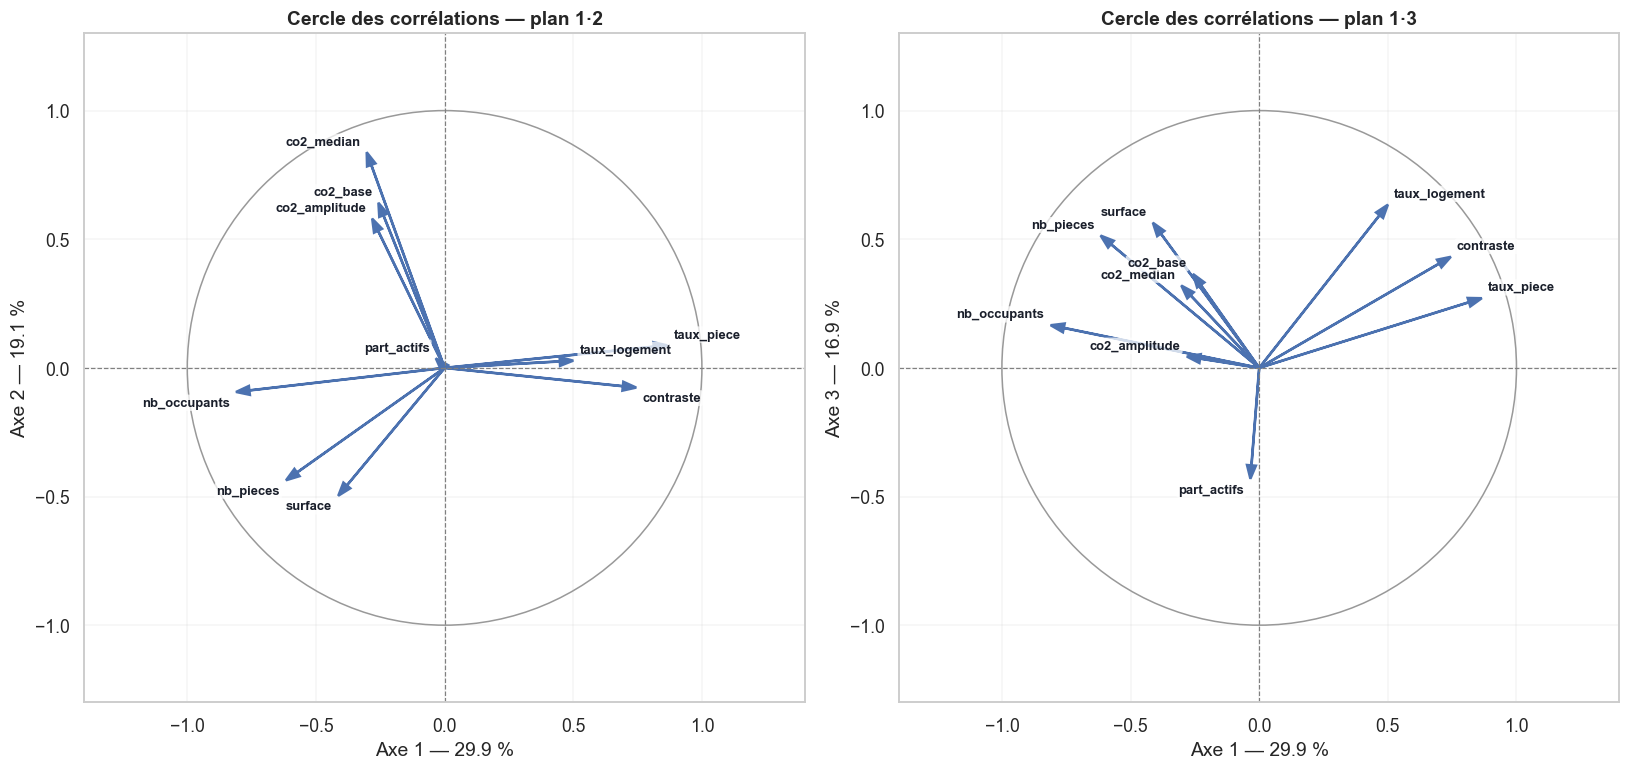

In [ ]:
# Cercle des corrélations 

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

for ax, (i, j) in zip(axes, [(0, 1), (0, 2)]):
    ax.add_patch(plt.Circle((0, 0), 1, fill=False, color='#999999', lw=1))
    for k, v in enumerate(VARS):
        ax.arrow(0, 0, charges[k, i], charges[k, j], head_width=0.035,
                 color='#4C72B0', lw=1.6, length_includes_head=True)
        etiquette(ax, charges[k, i], charges[k, j], v)
    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.axvline(0, color='grey', lw=0.8, ls='--')
    ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.3, 1.3); ax.set_aspect('equal')
    ax.set_xlabel(f'Axe {i+1} — {pct_acp[i]:.1f} %')
    ax.set_ylabel(f'Axe {j+1} — {pct_acp[j]:.1f} %')
    ax.set_title(f'Cercle des corrélations — plan {i+1}·{j+1}', fontweight='bold')
    ax.grid(True, alpha=0.2)

plt.tight_layout(); plt.show()


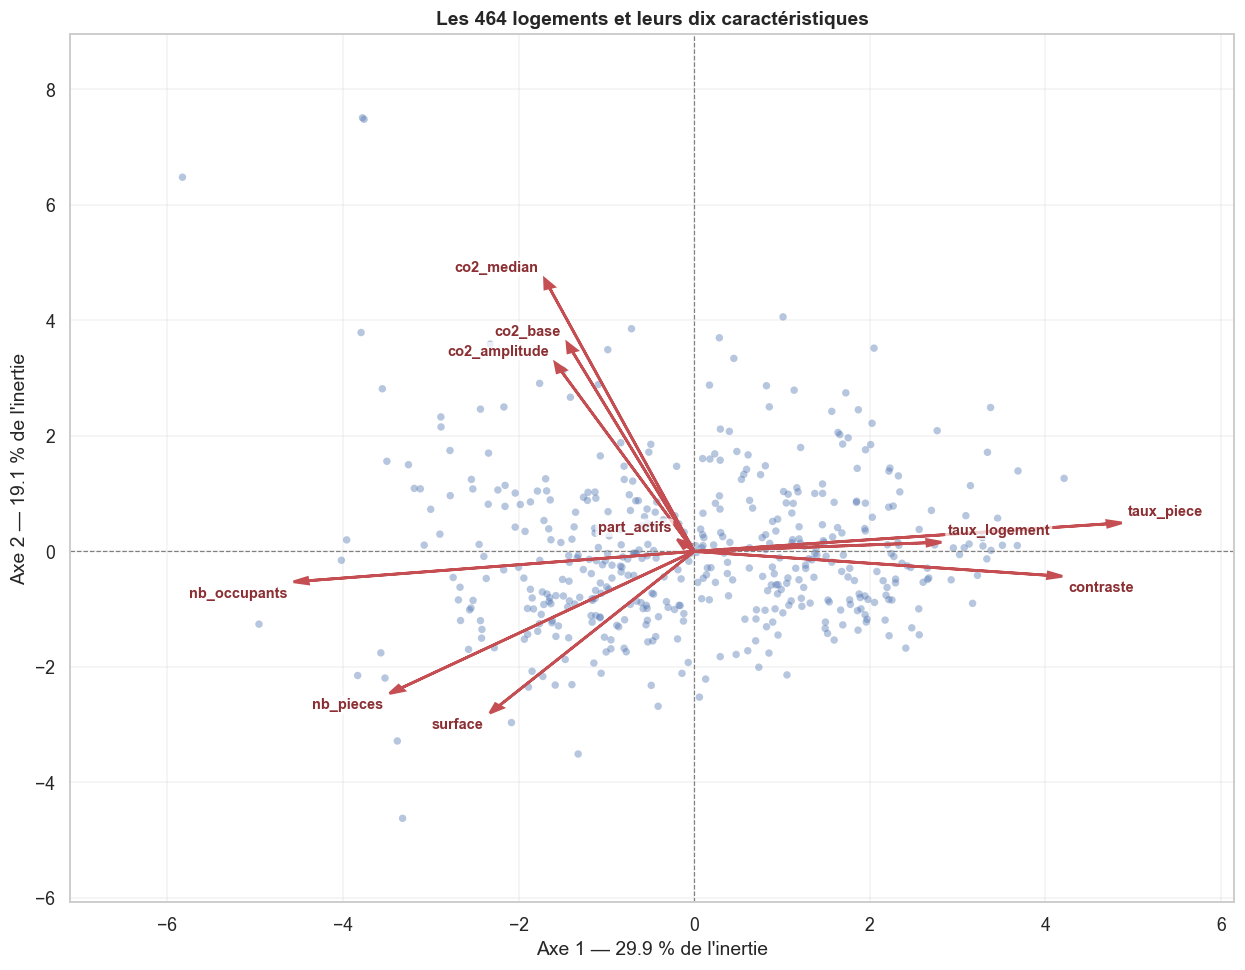

In [60]:
# Un point par logement, et les dix variables sur le même plan. Les flèches sont
# mises à l'échelle du nuage pour rester lisibles ; leurs longueurs relatives et
# leurs directions restent interprétables.
A = pd.DataFrame(C[:, :3], index=X.index, columns=['axe1', 'axe2', 'axe3'])
A['type_logement'] = num('FC3').map(FC3_LABELS)
A['ventilation']   = num('KVNT').map(KVNT_LABELS)
A['menage']        = num('STRMEN').map(STRMEN_LABELS)

fig, ax = plt.subplots(figsize=(11.5, 9))
ax.scatter(A['axe1'], A['axe2'], s=24, alpha=0.4, color='#4C72B0', edgecolors='none')

echelle = np.abs(C[:, :2]).max() * 0.75
for k, v in enumerate(VARS):
    x, y = charges[k, 0] * echelle, charges[k, 1] * echelle
    ax.arrow(0, 0, x, y, head_width=0.11, color='#C44E52', lw=1.8,
             length_includes_head=True, zorder=3)
    etiquette(ax, x, y, v, taille=9.5, couleur='#8B2F33')

ax.axhline(0, color='grey', lw=0.8, ls='--'); ax.axvline(0, color='grey', lw=0.8, ls='--')
ax.margins(0.12)
ax.set_xlabel(f"Axe 1 — {pct_acp[0]:.1f} % de l'inertie")
ax.set_ylabel(f"Axe 2 — {pct_acp[1]:.1f} % de l'inertie")
ax.set_title(f'Les {len(A)} logements et leurs dix caractéristiques', fontweight='bold')
ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()


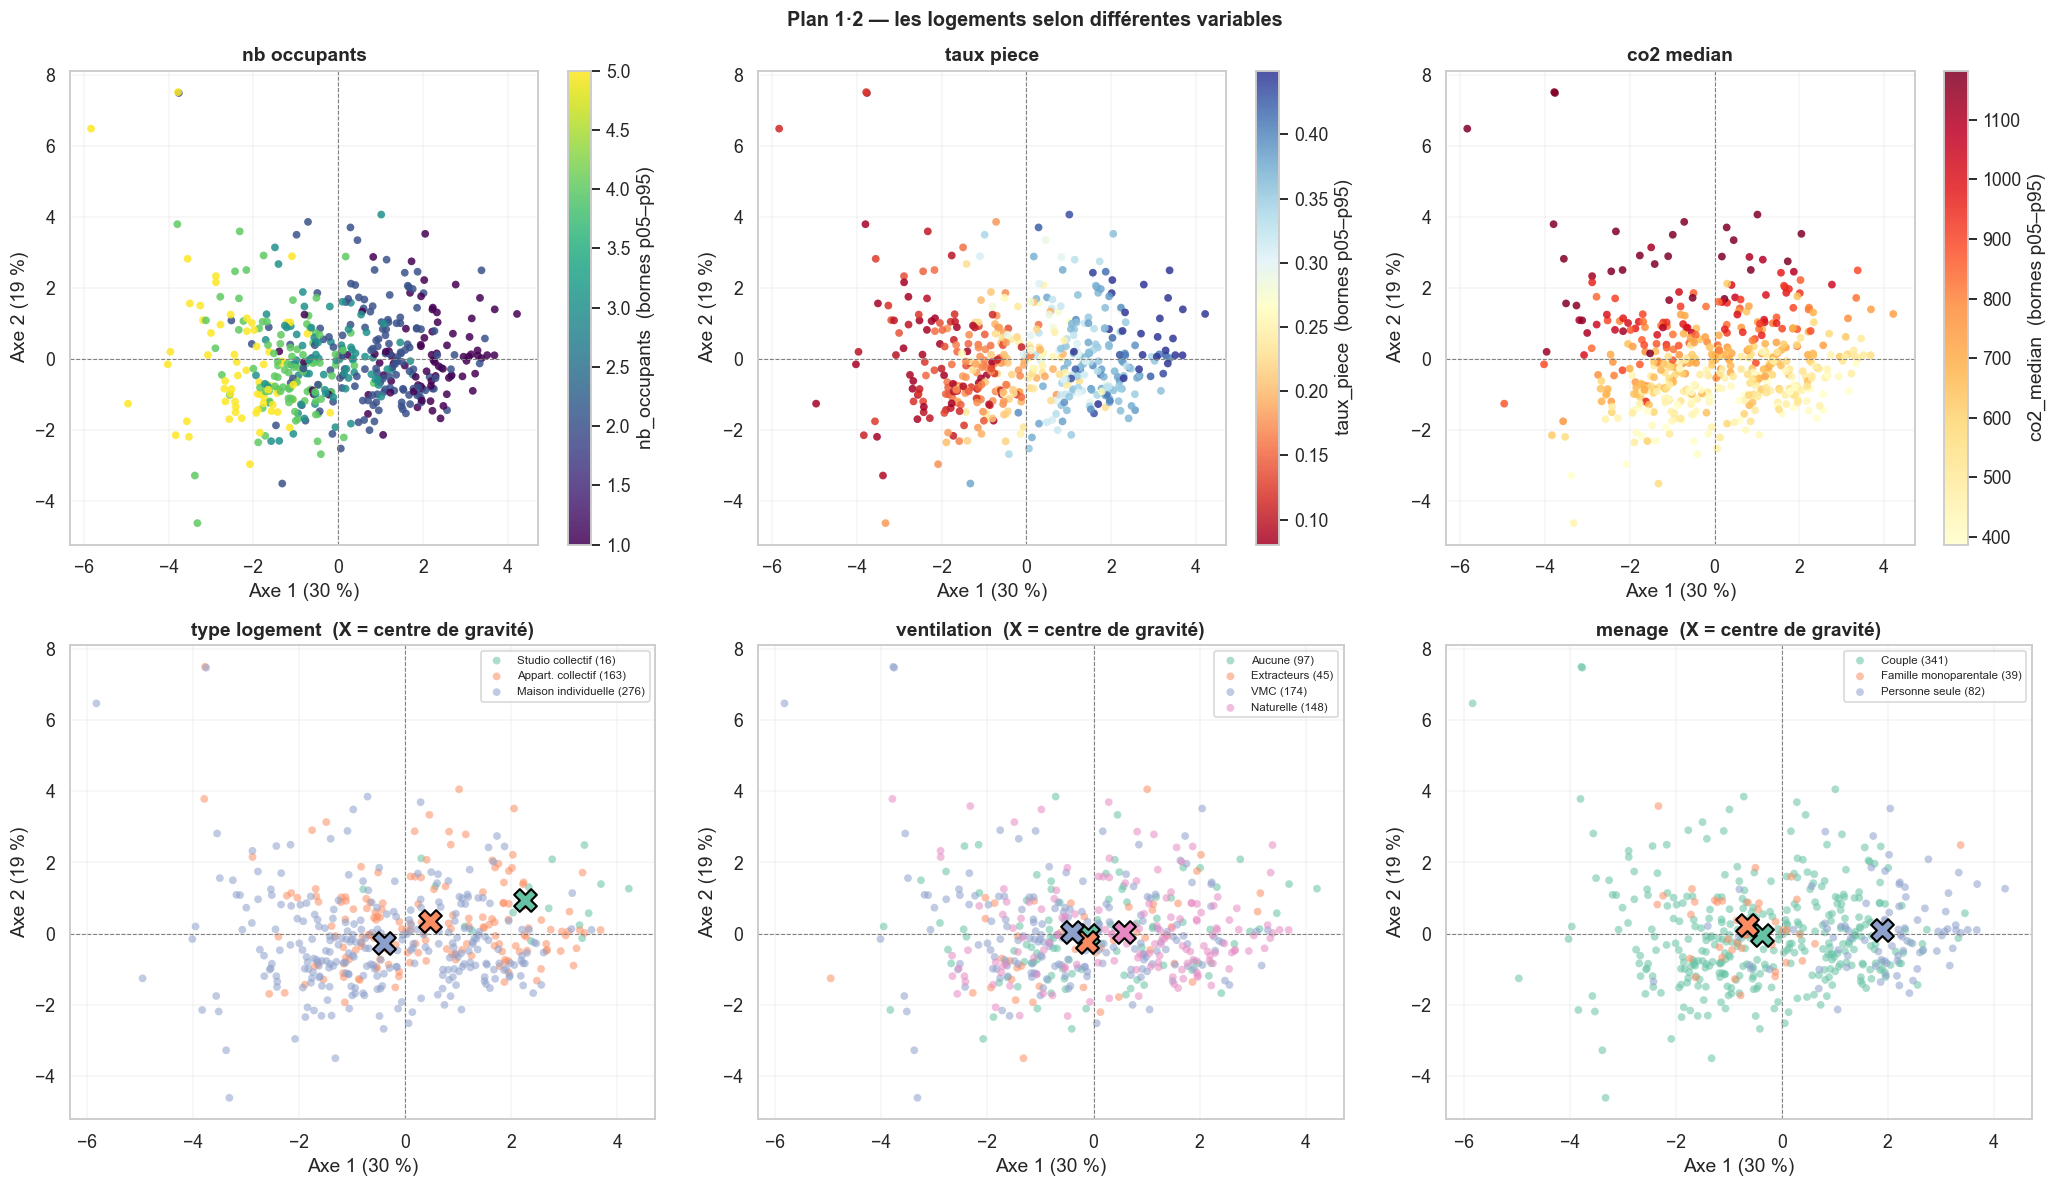

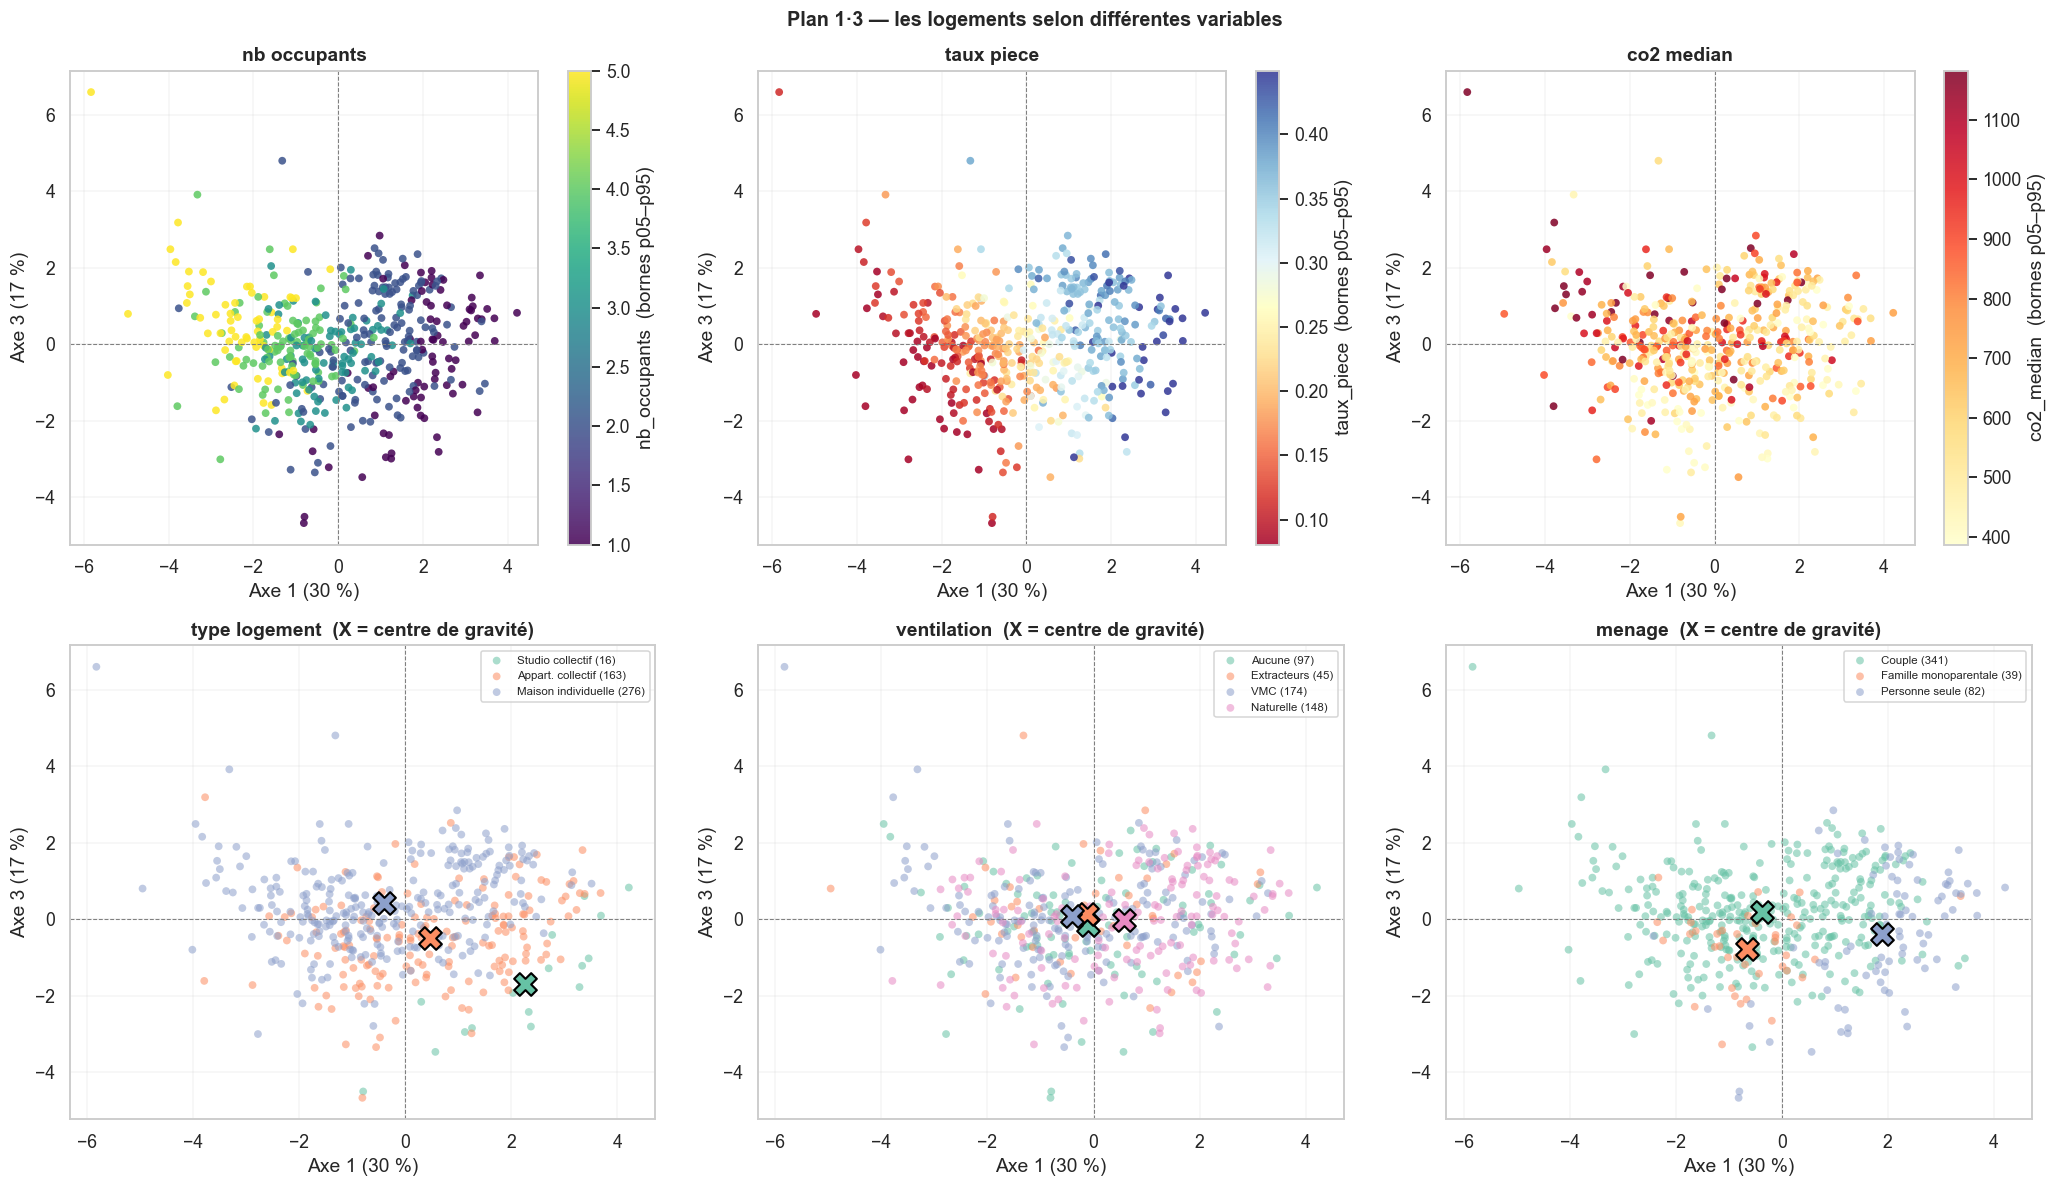

In [68]:
# Le même nuage, coloré par différentes variables, dans les deux plans factoriels.
# L'axe 3 pèse 16.9 %, presque autant que l'axe 2 (19.1 %) : s'en tenir au seul
# plan 1·2 laisserait de côté un tiers de l'information des trois premiers axes,
# et notamment tout ce que porte `taux_logement`, mal représenté en 1·2.

def nuage(k):
    """Grille de six panneaux dans le plan formé par l'axe 1 et l'axe k+1."""
    ay = f'axe{k + 1}'
    fig, axes = plt.subplots(2, 3, figsize=(19, 11))

    for ax, v, cmap in zip(axes[0], ['nb_occupants', 'taux_piece', 'co2_median'],
                           ['viridis', 'RdYlBu', 'YlOrRd']):
        # Bornes robustes : quelques logements très confinés écraseraient sinon
        # toute l'échelle de couleur et rendraient le reste du nuage uniforme.
        lo, hi = X[v].quantile([0.05, 0.95])
        sc = ax.scatter(A['axe1'], A[ay], c=X[v].clip(lo, hi), cmap=cmap, s=26,
                        alpha=0.85, edgecolors='none')
        plt.colorbar(sc, ax=ax, label=f'{v}  (bornes p05–p95)')
        ax.set_title(v.replace('_', ' '), fontweight='bold')

    for ax, v in zip(axes[1], ['type_logement', 'ventilation', 'menage']):
        sub = A.dropna(subset=[v])
        cats = [c for c in sub[v].unique() if (sub[v] == c).sum() >= 10]
        for cat, coul in zip(cats, sns.color_palette('Set2', len(cats))):
            m = sub[v] == cat
            ax.scatter(sub.loc[m, 'axe1'], sub.loc[m, ay], s=26, alpha=0.55,
                       color=coul, edgecolors='none', label=f'{cat} ({m.sum()})')
            ax.scatter(sub.loc[m, 'axe1'].mean(), sub.loc[m, ay].mean(), s=220,
                       color=coul, marker='X', edgecolors='black', linewidths=1.4,
                       zorder=5)
        ax.legend(fontsize=7.5, loc='best')
        ax.set_title(v.replace('_', ' ') + '  (X = centre de gravité)',
                     fontweight='bold')

    for ax in axes.ravel():
        ax.axhline(0, color='grey', lw=0.7, ls='--')
        ax.axvline(0, color='grey', lw=0.7, ls='--')
        ax.set_xlabel(f'Axe 1 ({pct_acp[0]:.0f} %)')
        ax.set_ylabel(f'Axe {k+1} ({pct_acp[k]:.0f} %)')
        ax.grid(True, alpha=0.2)

    plt.suptitle(f'Plan {1}·{k+1} — les logements selon différentes variables',
                 fontweight='bold', fontsize=13)
    plt.tight_layout(); plt.show()

for k in (1, 2):
    nuage(k)



In [ ]:
# Les catégories se séparent nettement sur l'axe 1.
print('Valeurs brutes moyennes par catégorie')
for v in ['type_logement', 'menage']:
    sub = A.dropna(subset=[v]).join(X[['nb_occupants', 'nb_pieces', 'taux_piece']])
    t = sub.groupby(v)[['nb_occupants', 'nb_pieces', 'taux_piece']].mean()
    t['n'] = sub.groupby(v).size()
    display(t[t['n'] >= 10].round(2))

# La ventilation, elle, ne figure pas dans l'ACP 
print("\nVentilation sur l'axe 1, à type de logement fixé")
for t_log in ['Maison individuelle', 'Appart. collectif']:
    sub = A[A['type_logement'] == t_log].dropna(subset=['ventilation'])
    grp = [g for _, g in sub.groupby('ventilation') if len(g) >= 10]
    if len(grp) < 2:
        continue
    p = kruskal(*[g['axe1'].values for g in grp]).pvalue
    moy = sub.groupby('ventilation')['axe1'].agg(['mean', 'size'])
    moy = moy[moy['size'] >= 10]
    print(f'\n  {t_log} — p = {p:.4f}')
    for nom, row in moy.iterrows():
        print(f'    {nom:<14}{row["mean"]:>7.2f}   (n = {int(row["size"])})')

# Une p-value dit qu'un écart existe
sd1 = C[:, 0].std()
print()
print(f"Ampleur des écarts sur l'axe 1 (écart-type de l'axe : {sd1:.2f})")
for v in ['type_logement', 'menage', 'ventilation']:
    s = A.dropna(subset=[v])
    t = s.groupby(v)['axe1'].agg(['mean', 'size'])
    t = t[t['size'] >= 10]
    hi, lo = t['mean'].idxmax(), t['mean'].idxmin()
    ecart = (t.loc[hi, 'mean'] - t.loc[lo, 'mean']) / sd1
    print(f'  {v:<16}{ecart:>5.2f} écart-type   '
          f'({hi} {t.loc[hi, "mean"]:+.2f}  vs  {lo} {t.loc[lo, "mean"]:+.2f})')


Valeurs brutes moyennes par catégorie


,nb_occupants,nb_pieces,taux_piece,n
type_logement,,,,
Appart. collectif,2.56,3.13,0.26,163
Maison individuelle,3.14,4.39,0.24,276
Studio collectif,1.25,1.00,0.49,16


,nb_occupants,nb_pieces,taux_piece,n
menage,,,,
Couple,3.32,4.13,0.24,341
Famille monoparentale,2.72,3.67,0.16,39
Personne seule,1.06,2.62,0.36,82



Ventilation sur l'axe 1, à type de logement fixé

  Maison individuelle — p = 0.0005
    Aucune          -0.48   (n = 65)
    Extracteurs     -0.42   (n = 26)
    Naturelle        0.29   (n = 72)
    VMC             -0.80   (n = 113)

  Appart. collectif — p = 0.2918
    Aucune           0.31   (n = 20)
    Extracteurs      0.23   (n = 17)
    Naturelle        0.75   (n = 66)
    VMC              0.28   (n = 60)

Ampleur des écarts sur l'axe 1 (écart-type de l'axe : 1.73)
  type_logement    1.53 écart-type   (Studio collectif +2.25  vs  Maison individuelle -0.40)
  menage           1.48 écart-type   (Personne seule +1.89  vs  Famille monoparentale -0.66)
  ventilation      0.57 écart-type   (Naturelle +0.58  vs  VMC -0.41)


## 7. Synthèse de l'ACP

### Trois axes, deux tiers de l'information

| Axe | Inertie | Variables qui le portent | Lecture |
|---|---|---|---|
| **1** | 29.9 % | `taux_piece` **+0.87**, `contraste` +0.74 · `nb_occupants` **−0.81**, `nb_pieces` −0.62 | concentration de l'occupation |
| **2** | 19.1 % | `co2_median` **+0.84**, `co2_base` +0.64, `co2_amplitude` +0.58 · `surface` −0.50 | niveau de confinement |
| **3** | 16.9 % | `taux_logement` +0.63, `surface` +0.56, `nb_pieces` +0.51 | présence au domicile |

Les trois premiers axes portent **66 %** de l'inertie : les dix variables se
résument à trois dimensions.

**L'axe 1 est celui de la concentration.** À une extrémité, un occupant seul dans un
petit logement : il passe l'essentiel de son temps dans la pièce du capteur, avec un
fort contraste nuit/jour. À l'autre, un ménage nombreux dans un grand logement : la
présence se disperse entre les pièces et le capteur n'en voit qu'une fraction.
C'est le mécanisme qui rendait les studios plus faciles à prédire (AUC 0.79 contre
0.97 pour les chambres, dans `analyse_erreurs.ipynb`) — l'ACP le retrouve ici comme
la **première source de variabilité** de l'échantillon.

**L'axe 2 est celui du confinement.** Les trois indicateurs de CO2 y pointent
ensemble, et la surface s'y oppose : un petit logement concentre le CO2 d'une même
respiration dans un volume moindre. C'est le pendant descriptif de l'analyse du
renouvellement d'air — ce que mesure le capteur dépend autant du volume et de la
ventilation que du nombre d'occupants.

**L'axe 3 sépare présence dans le logement et présence dans la pièce.** Grands
logements, occupants souvent au domicile mais dispersés entre les pièces.

### Les catégories se séparent — mais pour une raison mécanique

Contrairement à l'AFC, les variables qualitatives se distinguent ici très
nettement sur l'axe 1 (p < 0.0001 pour les trois), avec des écarts importants :

| Variable | Écart maximal entre catégories, axe 1 |
|---|---|
| Type de logement | 1.53 écart-type (studio +2.25 · maison −0.40) |
| Structure du ménage | 1.48 écart-type (personne seule +1.89 · monoparentale −0.66) |
| Ventilation | 0.57 écart-type |

**Ce n'est pas un résultat, c'est une vérification de cohérence.** Un studio a
1.00 pièce en moyenne, une personne seule compte 1.06 occupant — et `nb_pieces` et
`nb_occupants` sont précisément les variables qui portent l'axe 1. Ces catégories
se projettent loin parce que l'ACP contient déjà, sous forme continue,
l'information qu'elles véhiculent. La cellule de vérification l'établit sur les
valeurs brutes.

**La ventilation est le seul cas non mécanique** : elle ne figure pas dans l'ACP.
Elle sépare pourtant sur l'axe 1, mais l'effet ne survit qu'en maison individuelle
(p = 0.0005 ; ventilation naturelle +0.29 contre VMC −0.80) et disparaît en
appartement (p = 0.29). L'interprétation la plus économe reste indirecte : la VMC
est obligatoire dans le neuf depuis 1982, elle marque donc des maisons plus
récentes et plus grandes — soit, encore, l'axe de la taille.

**`part_actifs` reste sans place.** Elle ne dépasse 0.43 sur aucun axe — la plus mal
représentée des dix variables. Le statut professionnel du ménage ne structure pas
le nuage, cohérent avec les tests de `analyse_erreurs.ipynb` où l'écart entre
ménages sans contrainte horaire (0.975) et ménages à majorité d'actifs (0.954)
allait dans le sens inverse de l'intuition.

### Ce que les deux analyses disent ensemble

Le contraste entre les deux est instructif, précisément parce qu'elles ne
contiennent pas les mêmes variables.

L'**AFC** ne portait que sur le rythme horaire — aucune variable déclarée n'entrait
dans son calcul. Résultat : hormis le type de logement, rien ne s'y projetait
(ventilation p = 0.073, structure du ménage p = 0.18, présence d'un actif
p = 0.21), et l'axe 2 n'était expliqué par rien.

L'**ACP** contient la taille du logement et la composition du ménage. Les
catégories déclarées s'y alignent donc fortement — mais sur l'axe qui reprend ces
mêmes variables sous forme continue.

Autrement dit : les caractéristiques déclarées décrivent correctement **ce qu'est**
un logement — sa taille, son ménage, son niveau de CO2. Elles ne disent rien de
**quand il est occupé**. C'est le diagnostic de l'approche supervisée, obtenu ici
par une voie entièrement descriptive, et il explique rétrospectivement l'échec des
tentatives de clustering des journées CO2 : la variable qui structure réellement
les rythmes — l'heure à laquelle un ménage se couche et se lève — ne figure dans
aucun fichier de l'enquête.

### Réserves

**L'ACP suppose des relations linéaires.** Elle repose sur des corrélations de
Pearson ; un lien en cloche ou à seuil lui échapperait.

**Les variables ne sont pas indépendantes par construction.** `co2_median`,
`co2_base` et `co2_amplitude` proviennent de la même série et sont fortement
corrélées ; elles pèsent donc à trois sur l'axe 2. Un autre choix de variables
redistribuerait l'inertie sans, a priori, changer les oppositions identifiées.

**Les p-values sont sensibles à l'effectif.** Avec 464 logements, un écart faible
devient significatif. C'est pourquoi les écarts sont reportés ici en écarts-types
plutôt qu'en seules p-values.

**Le filtrage sur les valeurs renseignées** ne conserve que les logements complets
sur les dix variables. Rien ne garantit que les logements écartés leur ressemblent.


## 8. Une typologie des logements

L'ACP a produit trois axes interprétables, mais elle décrit un nuage continu : elle
situe chaque logement sans le ranger nulle part. On complète ici par une
**classification**, selon la chaîne classique de l'analyse des données française :
une classification ascendante hiérarchique sur les coordonnées factorielles, puis
une consolidation par **nuées dynamiques**.

**Pourquoi classer sur les axes plutôt que sur les dix variables brutes** : les axes
sont décorrélés, débarrassés des dimensions résiduelles, et déjà interprétés. Classer
dessus revient à classer sur l'information utile, sans la redondance des trois
indicateurs de CO2 qui pèseraient sinon à trois dans le calcul des distances.

**Une réserve posée d'emblée** : rien ne garantit qu'il existe des groupes. La
dernière cellule le teste explicitement, et la réponse conditionne la façon dont il
faut lire les classes obtenues.


,hauteur,saut
classes,,
2,43.17,19.29
3,23.87,2.12
4,21.75,1.71
5,20.04,1.27
6,18.77,0.99
7,17.79,5.20
8,12.59,0.70
9,11.89,0.12
10,11.76,1.27


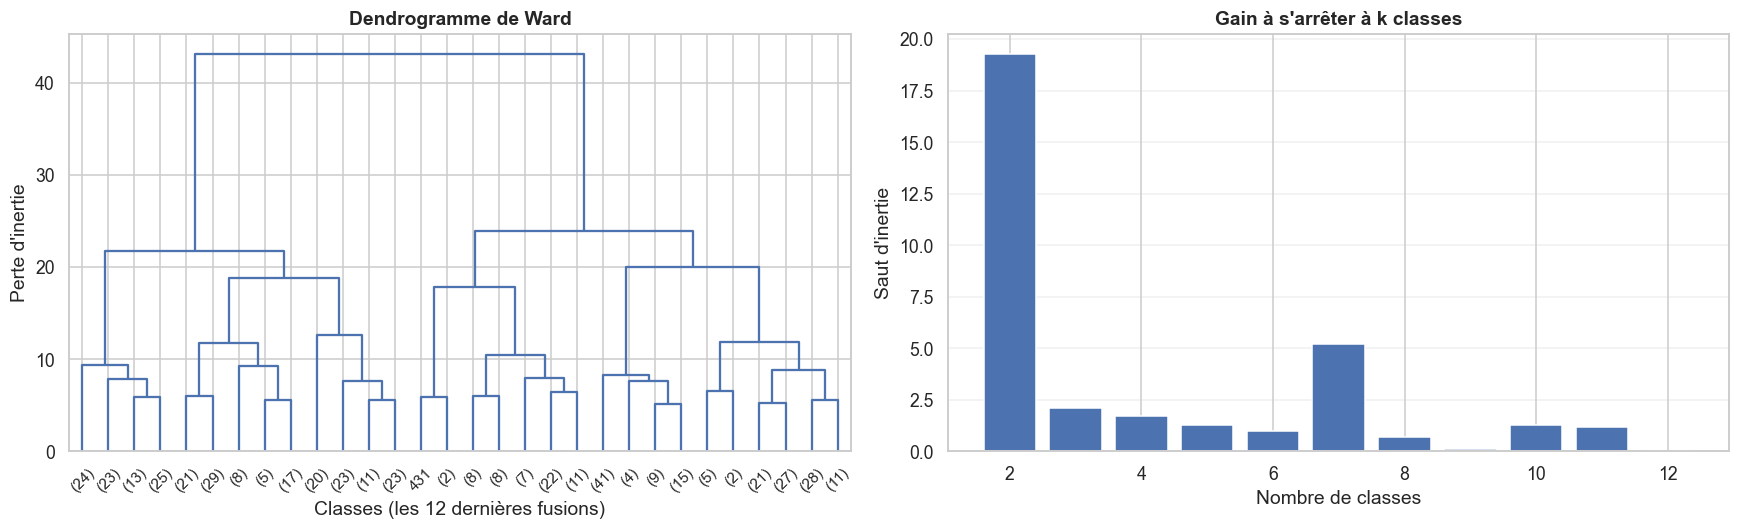

In [72]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score

# On classe sur les trois premiers axes, qui portent 66 % de l'inertie.
F = C[:, :3]

arbre = linkage(F, method='ward')
KMAX = 12
sauts = pd.DataFrame(
    {'hauteur': [arbre[-(k - 1), 2] for k in range(2, KMAX + 1)]},
    index=range(2, KMAX + 1))
sauts['saut'] = sauts['hauteur'] - sauts['hauteur'].shift(-1)
sauts.index.name = 'classes'
display(sauts.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
dendrogram(arbre, truncate_mode='lastp', p=30, ax=axes[0], color_threshold=0,
           above_threshold_color='#4C72B0')
axes[0].set_xlabel('Classes (les 12 dernières fusions)')
axes[0].set_ylabel("Perte d'inertie")
axes[0].set_title('Dendrogramme de Ward', fontweight='bold')

axes[1].bar(sauts.index, sauts['saut'].fillna(0), color='#4C72B0')
axes[1].set_xlabel('Nombre de classes'); axes[1].set_ylabel("Saut d'inertie")
axes[1].set_title("Gain à s'arrêter à k classes", fontweight='bold')
axes[1].grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

